# 83 - Transfer Learning by Hand: MNIST to Fashion-MNIST

**Section:** Transfer Learning | **Prereqs:** `Weight Initialization/FreezingWeightsDuringTraining.ipynb` | **Next:** `Transfer Learning/TF_ResNet-18.ipynb`

Train a CNN on MNIST, copy its weights into a fresh model, and continue training
on Fashion-MNIST. Transfer learning with nothing hidden.

**Why it works.** The first layers of any image CNN learn generic features -
edges, corners, strokes. Those are as useful for a shoe as for a 7. Only the
later layers are task-specific, so a model that has already learned to see is a
much better starting point than random noise.

**What transfers, and what does not**
- Similar domains (digits -> clothing, both 28x28 greyscale): most of it.
- Different input statistics or channel counts: the first layer usually cannot
  be reused.
- Different output classes: the final layer never transfers. Replace it.

**Note in the training function:** fewer epochs (10 instead of 25) and a much
smaller learning rate (1e-4 with Adam instead of 0.25 with SGD). That is the
point of fine-tuning - the model already knows most of what it needs, and large
updates would destroy it.

**Also worth reading:** the two training functions early in the notebook,
`train_model` and `train_model_fixed`. The first trains on raw 0-255 pixels at
lr=0.25 and is unstable; the second divides by 255 and lowers the rate. Keeping
both is a good record of a debugging session - the fix was scaling the input, not
changing the architecture.

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Dataset

import torchvision
import torchvision.transforms as T

from torchsummary import summary

from sklearn.model_selection import train_test_split


In [64]:
raw_data_train = torchvision.datasets.MNIST(root='/data', train=True, download=True)
raw_data_test = torchvision.datasets.MNIST(root='/data', train=False, download=True)

In [65]:
# MNIST, 90/10 train/validation split.
device = ('cuda' if torch.cuda.is_available() else 'cpu')

train_data , val_data , train_label, val_label = train_test_split(raw_data_train.data, raw_data_train.targets, test_size=0.10)

train_data = train_data.detach().clone().to(dtype=torch.float, device=device)
val_data = val_data.detach().clone().to(dtype=torch.float, device=device)

train_label = train_label.detach().clone().to(dtype=torch.long, device=device)
val_label = val_label.detach().clone().to(dtype=torch.long, device=device)

device

'cuda'

In [66]:
train_dataset = TensorDataset(train_data,train_label)
val_dataset = TensorDataset(val_data,val_label)

bs = 256
train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=val_dataset.tensors[0].shape[0])

In [67]:
train_loader, val_loader

(<torch.utils.data.dataloader.DataLoader at 0x7a4558812de0>,
 <torch.utils.data.dataloader.DataLoader at 0x7a4558605b50>)

In [68]:
# The CNN from CNNs/CNN_MNIST.ipynb: 1 -> 64 -> 128 -> 256 convs, global average
# pooling, then a small classifier.
class MNIST_Model(nn.Module):

  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(1,64, kernel_size=3, padding=1,stride=2)   # 28 -> 14, then pool -> 7
    self.conv2 = nn.Conv2d(64,128,kernel_size=3, padding=1, stride=1)  # 7 -> 7, then pool -> 3
    self.conv3 = nn.Conv2d(128,256,kernel_size=3, padding=1, stride=2)

    self.gap = nn.AdaptiveAvgPool2d((1,1))

    self.fc1 = nn.Linear(256,64)
    self.out = nn.Linear(64,10)


    self.pool = nn.MaxPool2d(2,2)


  def forward(self, x):

    x = self.pool(F.relu((self.conv1(x))))

    x =  self.pool(F.relu((self.conv2(x))))

    x =  self.pool(F.relu((self.conv3(x))))

    x = self.gap(x)

    x = x.view(x.size(0), -1)

    x = F.relu(self.fc1(x))

    return self.out(x)

In [69]:
model = MNIST_Model().to(device)
model

MNIST_Model(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (gap): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (out): Linear(in_features=64, out_features=10, bias=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)

In [70]:
# torchsummary - note the total parameter count, since all of it is about to be
# copied into a second model.
summary(model , (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 14, 14]             640
         MaxPool2d-2             [-1, 64, 7, 7]               0
            Conv2d-3            [-1, 128, 7, 7]          73,856
         MaxPool2d-4            [-1, 128, 3, 3]               0
            Conv2d-5            [-1, 256, 2, 2]         295,168
         MaxPool2d-6            [-1, 256, 1, 1]               0
 AdaptiveAvgPool2d-7            [-1, 256, 1, 1]               0
            Linear-8                   [-1, 64]          16,448
            Linear-9                   [-1, 10]             650
Total params: 386,762
Trainable params: 386,762
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.19
Params size (MB): 1.48
Estimated Total Size (MB): 1.67
-------------------------------------------

In [71]:
# The first attempt: raw 0-255 pixel values at lr=0.25. Unstable - see the fixed
# version in the next cell.
# x.unsqueeze(1) adds the channel axis: (N,28,28) -> (N,1,28,28).
def train_model():

  model = MNIST_Model().to(device)

  lossfunc = nn.CrossEntropyLoss()
  epochs = 25
  optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.25,
    momentum=0.9,
    )


  losses = []
  train_acc = []
  val_acc = []

  for epoch in range(epochs):

    model.train()

    batch_acc = []
    batch_loss = []

    for x,y in train_loader:
      x = x.unsqueeze(1) # Add channel dimension
      yhat = model(x)

      loss = lossfunc(yhat,y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      acc = 100 * torch.mean( (torch.argmax(yhat, dim=1) == y).float().detach().cpu())
      batch_acc.append(acc)

    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))

    # Now validation

    model.eval()
    with torch.no_grad():
      X,Y = next(iter(val_loader))
      X = X.to(device)
      Y = Y.to(device)
      X = X.unsqueeze(1) # Add channel dimension for validation data
      val_acc.append( 100 * torch.mean( (torch.argmax(model(X), dim=1) == Y).float().detach().cpu()) )


    if epoch % 10 == 0 or epoch == epochs-1 :
      print(f'Epoch {epoch} | Loss : {losses[epoch]:.4f} | Train Acc {train_acc[epoch]} | Val Acc : {val_acc[epoch]}')

  return model, losses, train_acc, val_acc

In [72]:
# The fix: divide by 255 and drop the learning rate to 0.01.
# Worth reading against the previous cell - the problem was the INPUT SCALE, not
# the architecture. Unscaled inputs make activations and gradients large, so no
# sane learning rate works.
# This is the version that actually runs (it trains at the bottom of the cell).
def train_model_fixed():

  model = MNIST_Model().to(device)

  lossfunc = nn.CrossEntropyLoss()
  epochs = 25
  optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01, # Reduced learning rate
    momentum=0.9,
    )


  losses = []
  train_acc = []
  val_acc = []

  for epoch in range(epochs):

    model.train()

    batch_acc = []
    batch_loss = []

    for x,y in train_loader:
      # Add channel dimension and normalize input data
      x = x.unsqueeze(1) / 255.0
      yhat = model(x)

      loss = lossfunc(yhat,y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      acc = 100 * torch.mean( (torch.argmax(yhat, dim=1) == y).float().detach().cpu())
      batch_acc.append(acc)

    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))

    # Now validation

    model.eval()
    with torch.no_grad():
      X,Y = next(iter(val_loader))
      X = X.to(device)
      Y = Y.to(device)
      # Add channel dimension and normalize input data for validation
      X = X.unsqueeze(1) / 255.0
      val_acc.append( 100 * torch.mean( (torch.argmax(model(X), dim=1) == Y).float().detach().cpu()) )


    if epoch % 10 == 0 or epoch == epochs-1 :
      print(f'Epoch {epoch} | Loss : {losses[epoch]:.4f} | Train Acc {train_acc[epoch]} | Val Acc : {val_acc[epoch]}')

  return model, losses, train_acc, val_acc

model, losses, train_acc, val_acc = train_model_fixed()

Epoch 0 | Loss : 1.9354 | Train Acc 46.35044479370117 | Val Acc : 75.13333892822266
Epoch 10 | Loss : 0.0476 | Train Acc 98.4765625 | Val Acc : 98.25
Epoch 20 | Loss : 0.0213 | Train Acc 99.30245208740234 | Val Acc : 98.46666717529297
Epoch 24 | Loss : 0.0169 | Train Acc 99.46800231933594 | Val Acc : 98.6500015258789


In [73]:
# Confirms the trained model's shape before copying.
model.fc1.weight.shape

torch.Size([64, 256])

## Now we use the trained model on MNIST, and use it as a strating point for FMNIST

In [74]:
# THE TRANSFER. A fresh model with the same architecture and random weights, then
# every parameter copied across with deepcopy.
#
# In practice you would use the state_dict:
#   FMNIST_model.load_state_dict(model.state_dict())
# which is shorter and validates the shapes. The explicit loop is here to show
# what the copy actually is.
#
# The output layer is copied too. Both tasks have 10 classes, so the shape fits -
# but the classes MEAN different things, so those weights are near-useless and
# will simply be retrained. With a different class count you would have to
# replace that layer, as the ResNet and VGG notebooks do.
import copy

# Copying model
FMNIST_model = MNIST_Model() # We initailized using the same arch, but random weights.

# Now we copy weight:
for source,target in zip(model.named_parameters(), FMNIST_model.named_parameters()):
    target[1].data = copy.deepcopy(source[1].data)

In [75]:
# Verifying the copy: torch.equal on every tensor in both state_dicts.
# Always check a transfer actually happened - a silent no-op here would look
# exactly like 'transfer learning did not help'.
all_same = True
for target, source in zip(FMNIST_model.state_dict().values(), model.state_dict().values()):
    if not torch.equal(target, source): #torch.equal(tensor1, tensor2) is a PyTorch function that checks if two tensors are exactly the same
        all_same = False
        break

if all_same:
    print("All weights are the same")
else:
    print("Weights are different")

All weights are the same


In [76]:
# Fashion-MNIST: same shape as MNIST, different content.
data = torchvision.datasets.FashionMNIST(root='/root', download=True,train=True)
data_test = torchvision.datasets.FashionMNIST(root='/root', download=True,train=False)

In [77]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')

train_data = data.data
train_label = data.targets

val_data = data_test.data
val_label = data_test.targets

In [78]:
# Loaders. Note the reshape adds the channel axis here rather than in the loop.
train_dataset = TensorDataset(train_data.reshape(train_data.shape[0],1,28,28).float().to(device), train_label.long().to(device))
val_dataset = TensorDataset(val_data.reshape(val_data.shape[0],1,28,28).float().to(device), val_label.long().to(device))

bs = 256
train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=val_data.shape[0])


In [79]:
# Fine-tuning: 10 epochs at lr=1e-4 with Adam, and no layers frozen.
# Both choices are the essence of fine-tuning - fewer epochs and a much smaller
# learning rate than training from scratch, because the model starts already
# knowing most of what it needs.
def train_model():

  lossfunc = nn.CrossEntropyLoss()
  epochs = 10
  optimizer = torch.optim.Adam(
    FMNIST_model.parameters(), # Corrected: Optimize FMNIST_model parameters
    lr=1e-4,
    weight_decay=5e-4,
    betas=(0.9, 0.999)
)


  losses = []
  train_acc = []
  val_acc = []

  # l1_lambda = 5e-4 # Removed L1 regularization parameter

  for epoch in range(epochs):

    FMNIST_model.train()

    batch_acc = []
    batch_loss = []

    for x,y in train_loader:
      x = x / 255.0 # Added: Normalize input data
      yhat = FMNIST_model(x)

      loss = lossfunc(yhat,y)

      # Removed L1 regularization calculation:
      # l1_norm = sum(p.abs().sum() for p in FMNIST_model.parameters())
      # num_parameters = sum(p.numel() for p in FMNIST_model.parameters())
      # loss = loss + l1_lambda * (l1_norm / num_parameters)

      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      acc = 100 * torch.mean( (torch.argmax(yhat, dim=1) == y).float().detach().cpu())
      batch_acc.append(acc)

    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))

    # Now validation

    FMNIST_model.eval() # Corrected: Use FMNIST_model for evaluation
    with torch.no_grad():
      X,Y = next(iter(val_loader))
      X = X.to(device)
      Y = Y.to(device)
      X = X / 255.0 # Added: Normalize input data for validation
      val_acc.append( 100 * torch.mean( (torch.argmax(FMNIST_model(X), dim=1) == Y).float().detach().cpu()) )


    if epoch % 10 == 0 or epoch == epochs-1 :
      print(f'Epoch {epoch} | Loss : {losses[epoch]:.4f} | Train Acc {train_acc[epoch]} | Val Acc : {val_acc[epoch]}')

  return FMNIST_model, losses, train_acc, val_acc

In [80]:
FMNIST_model, losses, train_acc, val_acc = train_model()

Epoch 0 | Loss : 1.0377 | Train Acc 67.66493225097656 | Val Acc : 79.81999969482422
Epoch 9 | Loss : 0.3078 | Train Acc 88.94063568115234 | Val Acc : 87.62999725341797


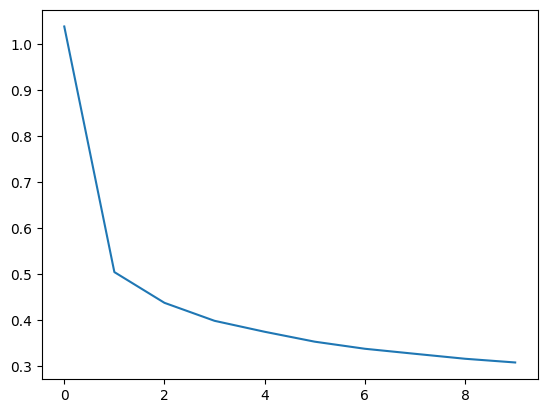

In [81]:
# Loss curve. Compare where it STARTS against the from-scratch runs: a
# transferred model begins at a much lower loss, which is the benefit in one
# picture.
plt.plot(losses);

#### NOTE : We train the model less when we are transfering learning from another model, that's the whole point of TF.